# **Indian Sign Language Detecion**

## **Installing libraries**

In [1]:
!pip install ultralytics
from IPython import display
display.clear_output()

### **Checking Ultralytics version and System Specs**

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


### **Downloading YOLO v11 Medium Model**

In [3]:
from ultralytics import YOLO
model = YOLO("yolo11m.pt")

### **Setting the dataset path**

In [4]:
dataset_path = "/kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11"

### **Model Training Configuration**

In [5]:
model.train(
    data="/kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/data.yaml",
    epochs=200,
    imgsz=640,
    batch=48,          
    device=[0,1],   #To use both T4 GPU
    cache=True,     #To use RAM to cache the data   
    optimizer="AdamW",
    momentum=0.9,
    lr0=0.001,
    lrf=0.01,           
    weight_decay=0.0005,
    warmup_epochs=3,  # Initial low LR period to stabilize weights before peak learning
    warmup_bias_lr=0.1,
    cos_lr=True,
    box=7.5,         # Higher value makes the model fight harder for perfect box overlap
    cls=1.5,         # Higher value helps with identifying low-count classes

    # Some Color Space Augmentation
    hsv_h = 0.015,
    hsv_s = 0.7,
    hsv_v = 0.4,

    #Some Geometric Transformations
    degrees = 10.0,
    translate = 0.1,
    scale = 0.5,
    shear = 10.0,
    perspective = 0.001,
    fliplr = 0.5,
    mosaic = 1.0,
)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/data.yaml, degrees=10.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.9, m

### **Listing the results files**

In [6]:
!ls /kaggle/working/runs/detect/train

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch16910.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch16911.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch16912.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg      weights
labels.jpg			 train_batch2.jpg


### **Showcasing the Confusion matrix**

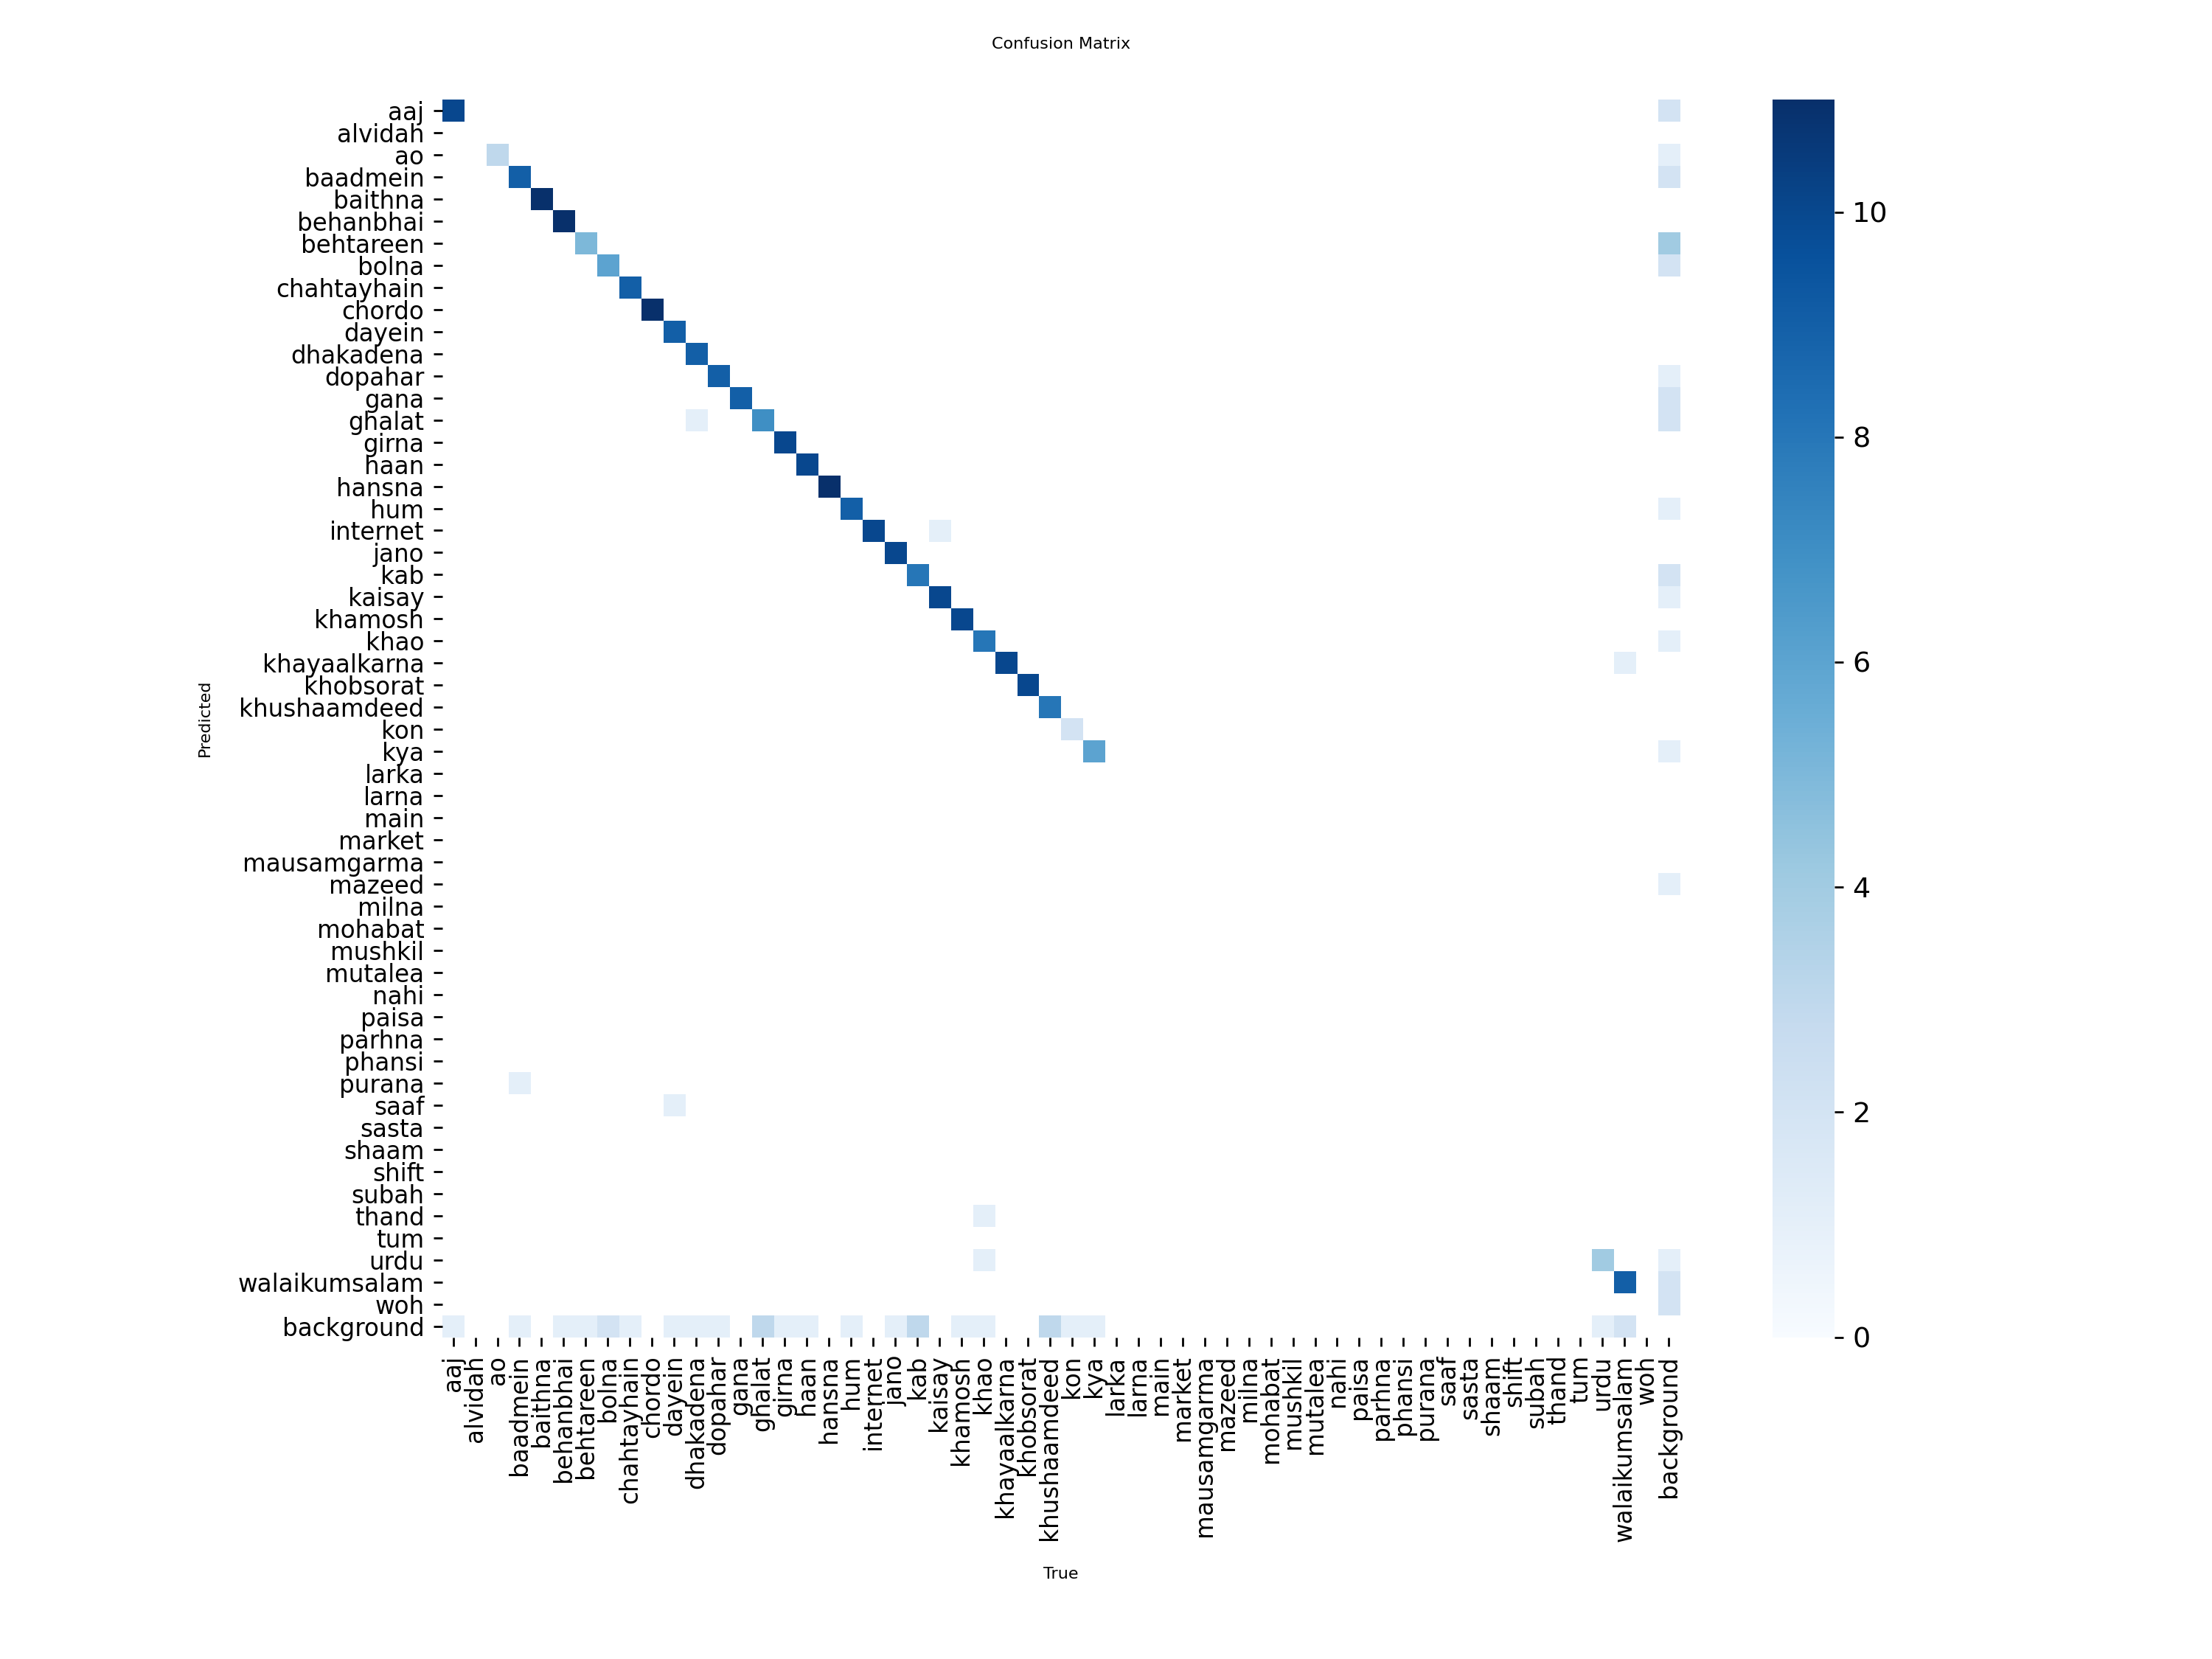

In [7]:
from IPython.display import Image,display
resultData=('/kaggle/working/runs/detect/train')
Image(filename=f'{resultData}/confusion_matrix.png')

### **Showcasing the Confusion matrix normalized**

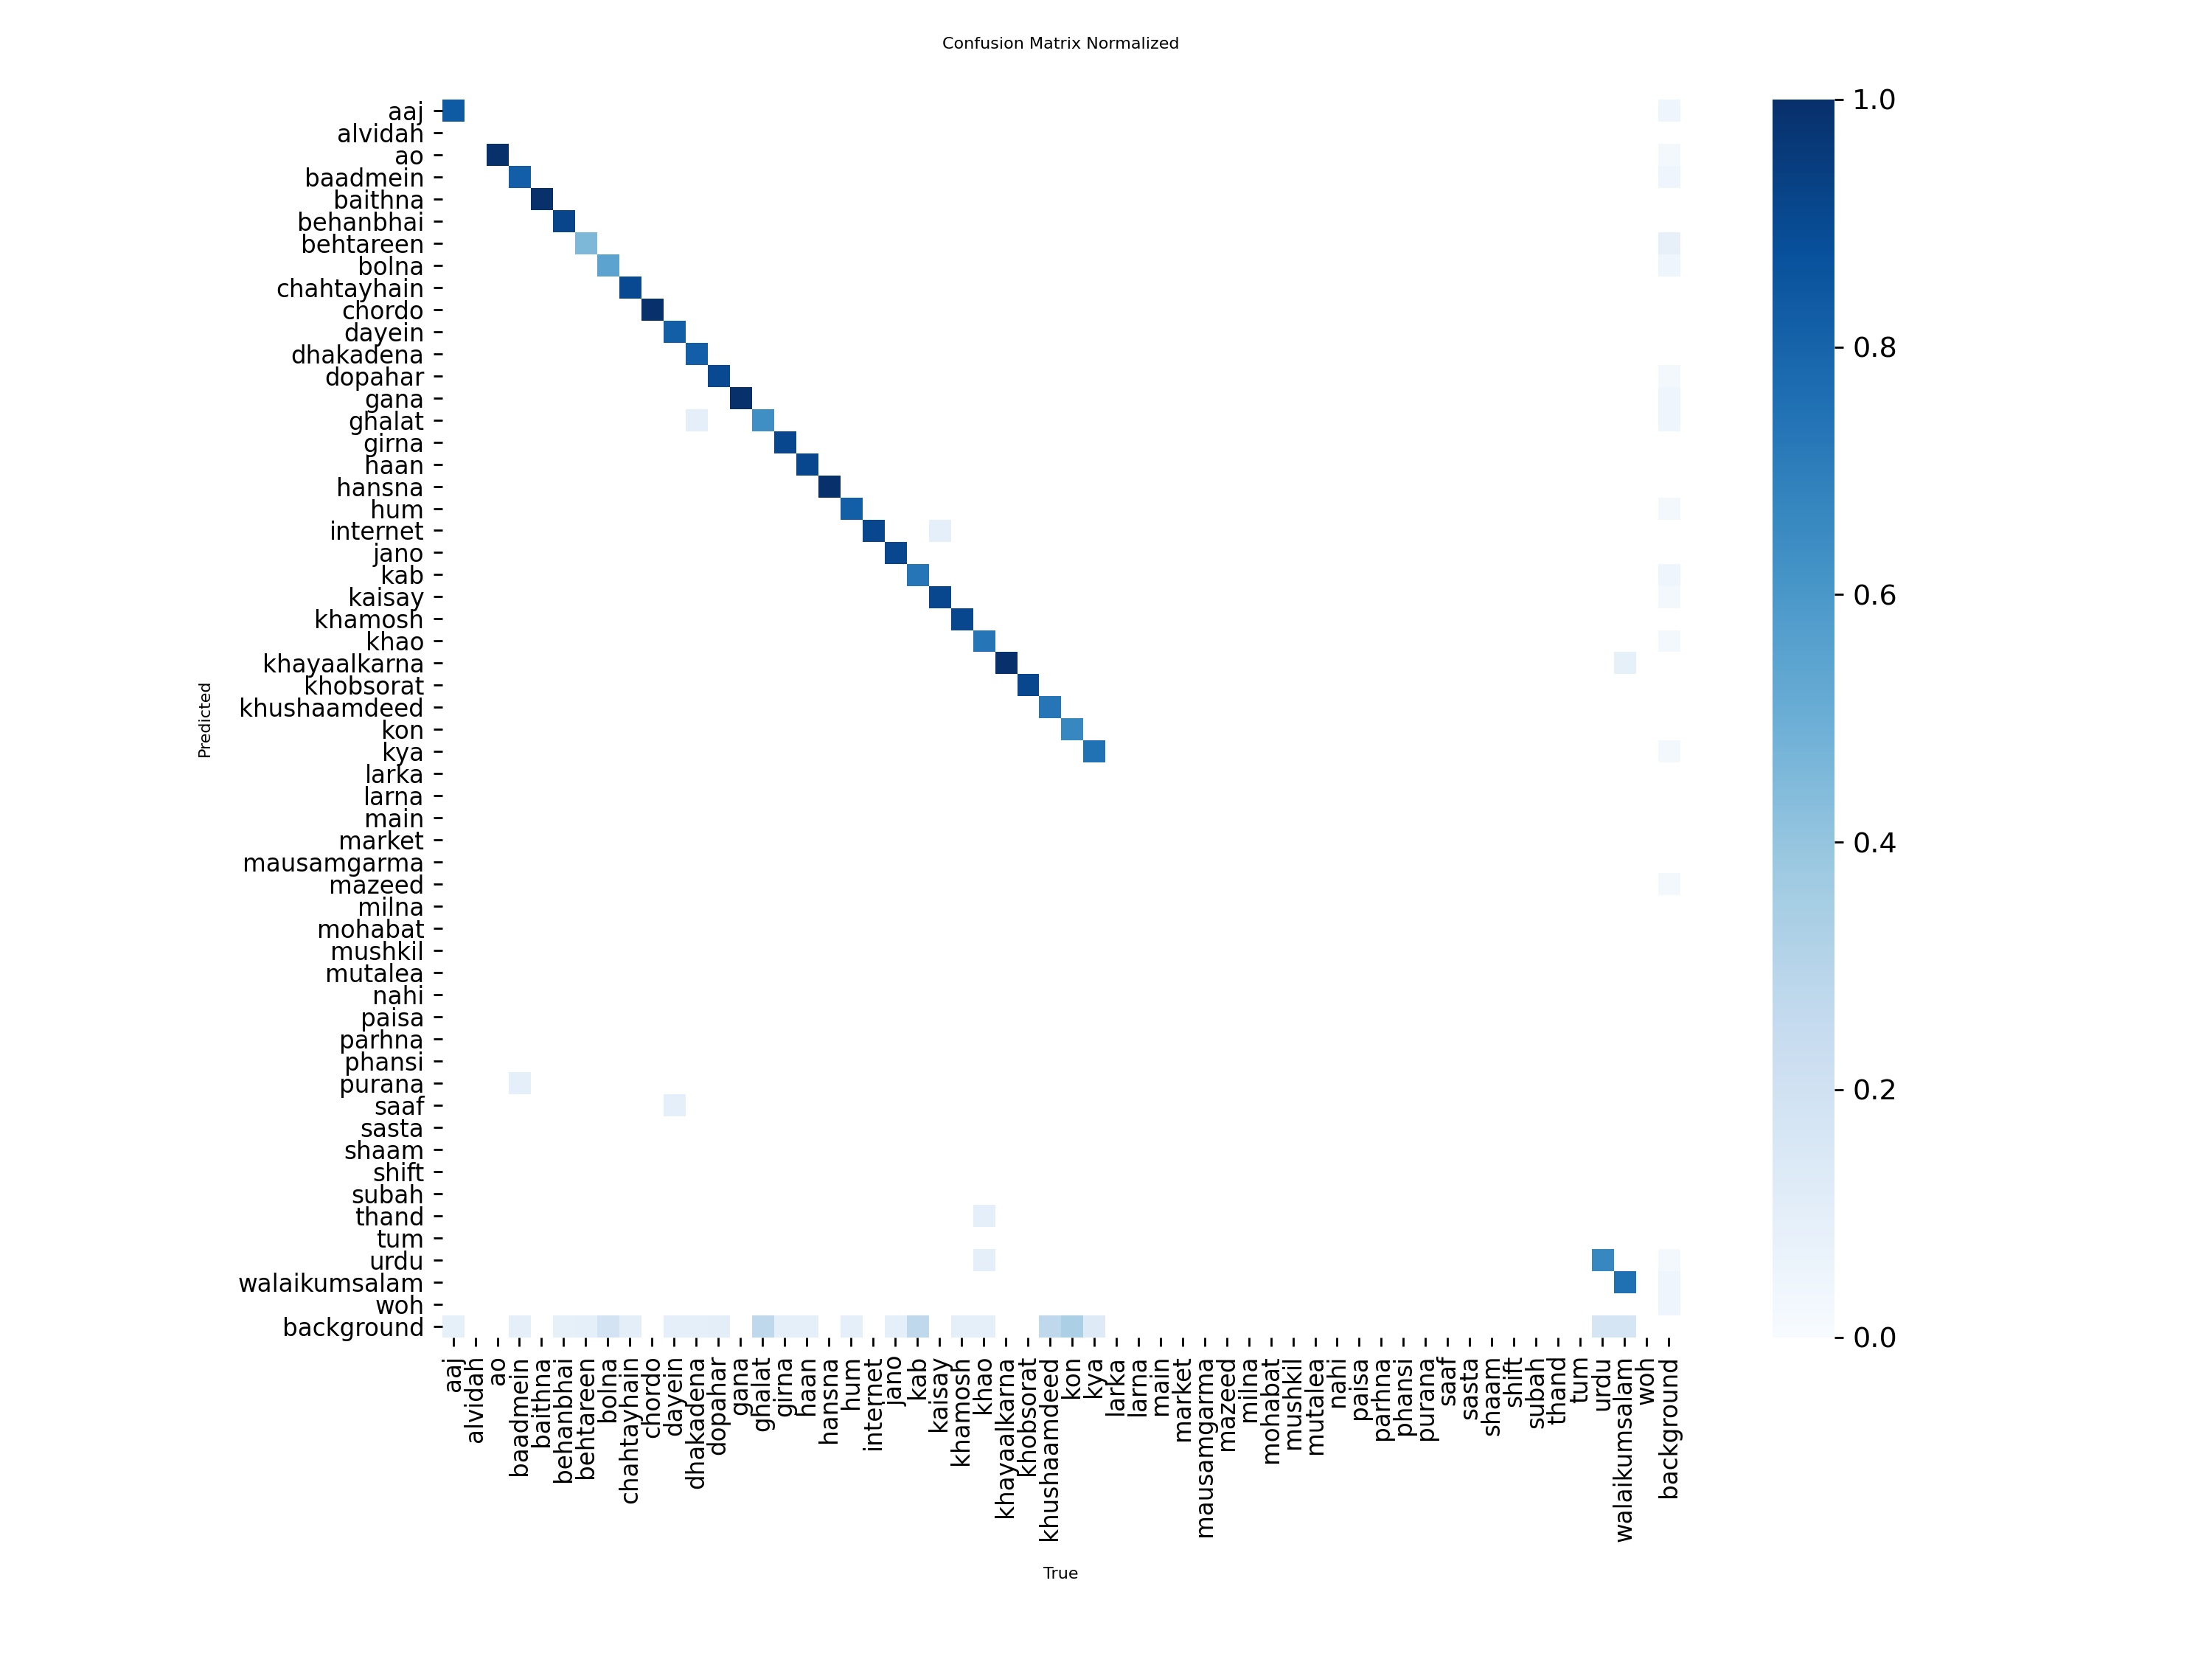

In [8]:
from IPython.display import Image,display
resultData=('/kaggle/working/runs/detect/train')
Image(filename=f'{resultData}/confusion_matrix_normalized.png')

### **Showcasing the Result data**

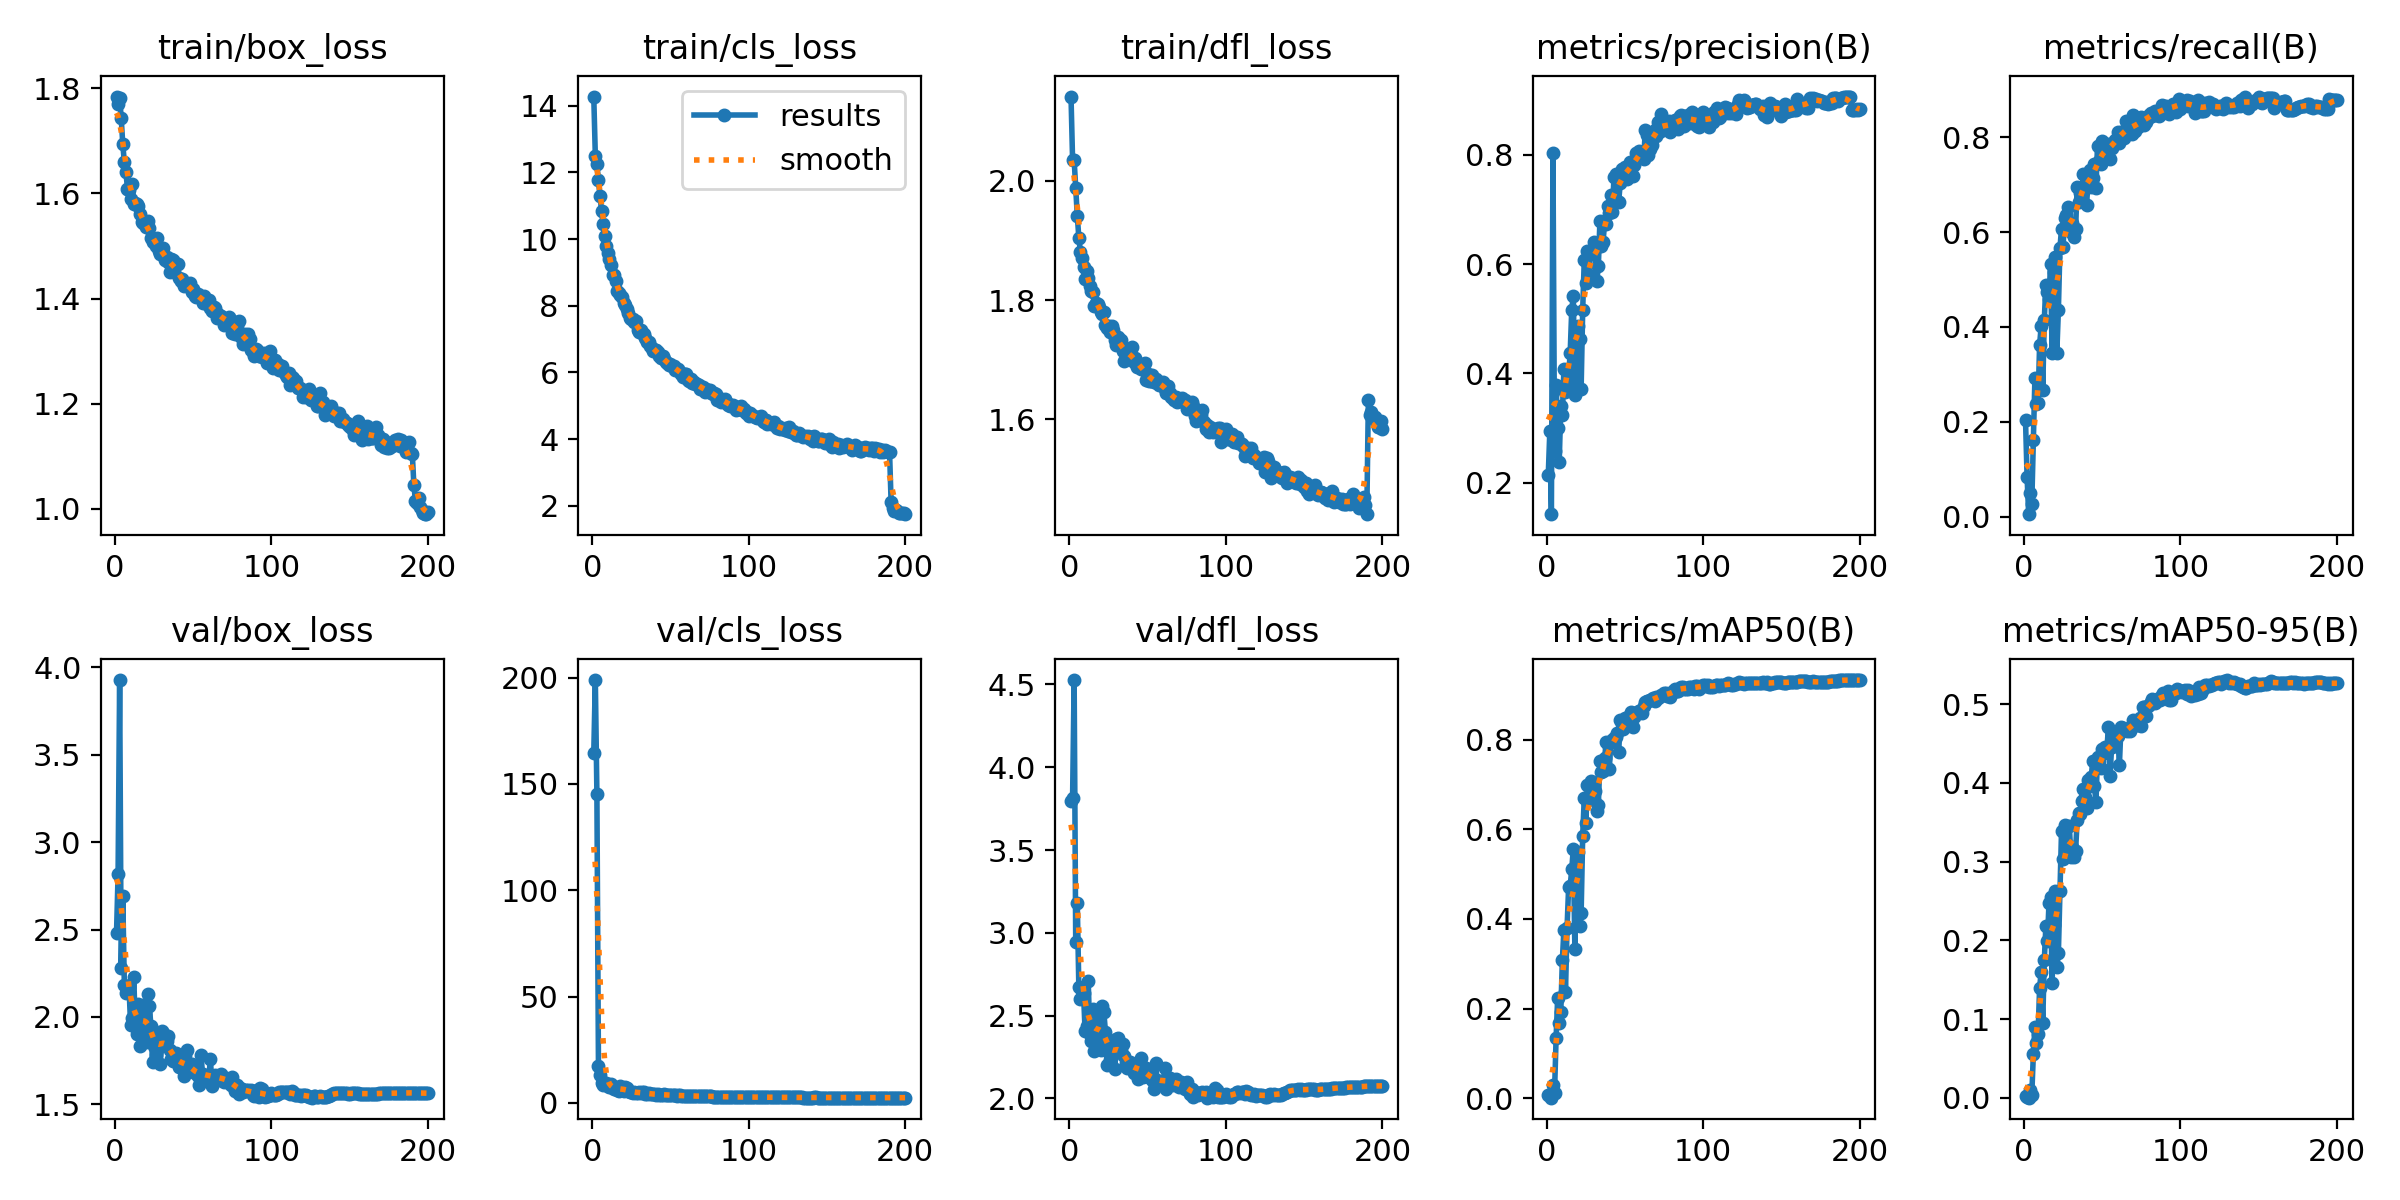

In [9]:
resultData=('/kaggle/working/runs/detect/train')
Image(filename=f'{resultData}/results.png')

### **Showcasing the result.csv data**

In [10]:
import pandas as pd
resultData = '/kaggle/working/runs/detect/train/'
df = pd.read_csv(f'{resultData}results.csv')
print(df.head(5))

   epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1  116.993         1.78385         14.2768         2.14131   
1      2  214.300         1.76905         12.4986         2.03506   
2      3  329.220         1.78187         12.2423         2.03516   
3      4  425.539         1.74272         11.7606         1.98740   
4      5  521.891         1.69323         11.2802         1.94175   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.21438            0.20285           0.00792   
1               0.29488            0.08347           0.00620   
2               0.14280            0.00496           0.00095   
3               0.80329            0.04955           0.02965   
4               0.25841            0.02719           0.01216   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.00220       2.47853      164.5300       3.79378  0.000330   
1              0.00165       2.81491      19

In [11]:
import pandas as pd
df=pd.read_csv(f'{resultData}results.csv')
print(df.tail(1))

     epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
199    200  19031.6         0.99367         1.74726         1.58351   

     metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
199               0.88345             0.8782           0.93311   

     metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0  \
199              0.52666       1.56396       2.46403       2.07575  0.00001   

      lr/pg1   lr/pg2  
199  0.00001  0.00001  


### **Performing vadilation on testing dataset**

In [12]:
model.val(
    data='/kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/data.yaml',
    split='test',
    save_json=True,
    conf=0.25
)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,114,842 parameters, 0 gradients, 68.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5.2±2.0 MB/s, size: 30.2 KB)
val: Scanning /kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test/labels... 552 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 552/552 193.4it/s 2.9s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 1.9it/s 18.6s
                   all        552        552      0.879       0.88      0.864       0.51
                   aaj          5          5        0.5        0.6      0.595      0.293
                  acha          5          5       0.75        0.6      0.595      0.416
               alvidah         

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a5a6045c470>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.0

### **Performing prediction on testing dataset**

In [13]:
results = model.predict(source='/kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test/images', conf=0.25, save=True)


image 1/552 /kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test/images/Dopahar_1_jpg.rf.c817013bec2c81ddfd7527bc3b98894a.jpg: 640x640 1 dopahar, 37.2ms
image 2/552 /kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test/images/Dopahar_20_jpg.rf.6629eb198c964e7d770b5b02f6a987c7.jpg: 640x640 1 dopahar, 37.2ms
image 3/552 /kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test/images/Dopahar_2_jpg.rf.a6e6ec689e539338dcdcfa74cbecb5e4.jpg: 640x640 2 dopahars, 28.4ms
image 4/552 /kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test/images/Dopahar_43_jpg.rf.3096c167e1c6d58c823bf9d8a9d41d56.jpg: 640x640 (no detections), 28.4ms
image 5/552 /kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test/images/Dopahar_47_jpg.rf.838d72db2268a102d28b5a76158fad76.jpg: 640x640 2 dopahars, 28.4ms
image 6/552 /kaggle/input/datasets/thedebugger2025/hinglish/Sign Language.v1i.yolov11/test/im

### **Displaying the 10 first predicted images**

Found 552 predicted images. Displaying the first 10:
Displaying image 1: Dopahar_1_jpg.rf.c817013bec2c81ddfd7527bc3b98894a.jpg


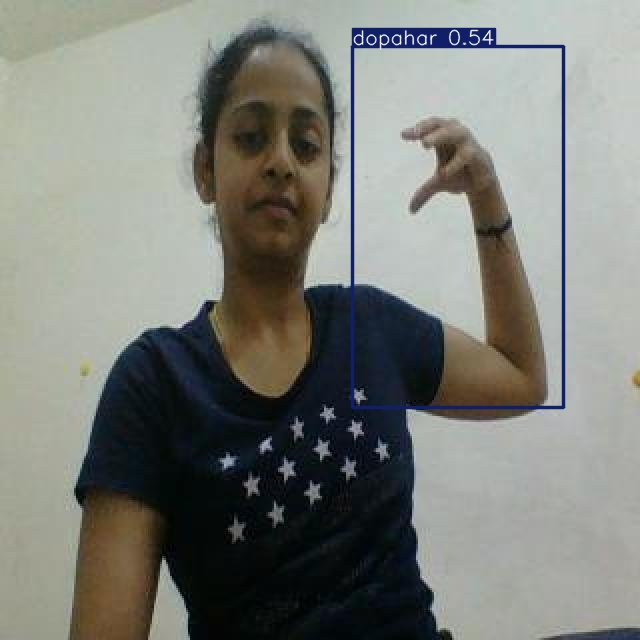

Displaying image 2: Dopahar_20_jpg.rf.6629eb198c964e7d770b5b02f6a987c7.jpg


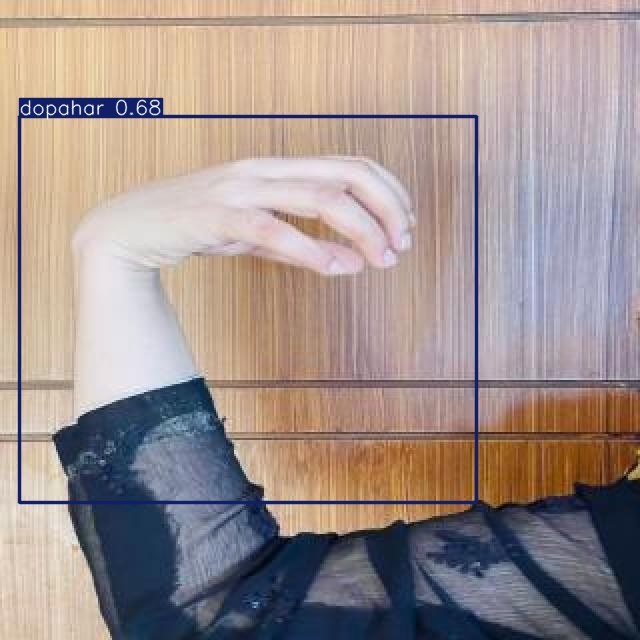

Displaying image 3: Dopahar_2_jpg.rf.a6e6ec689e539338dcdcfa74cbecb5e4.jpg


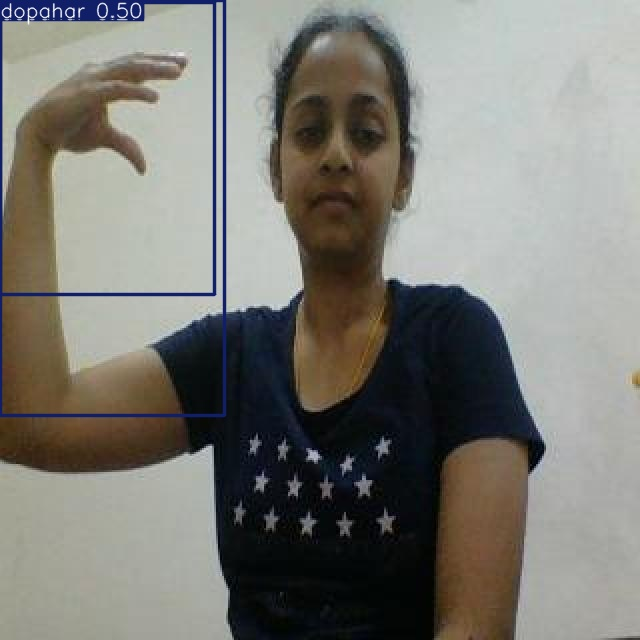

Displaying image 4: Dopahar_43_jpg.rf.3096c167e1c6d58c823bf9d8a9d41d56.jpg


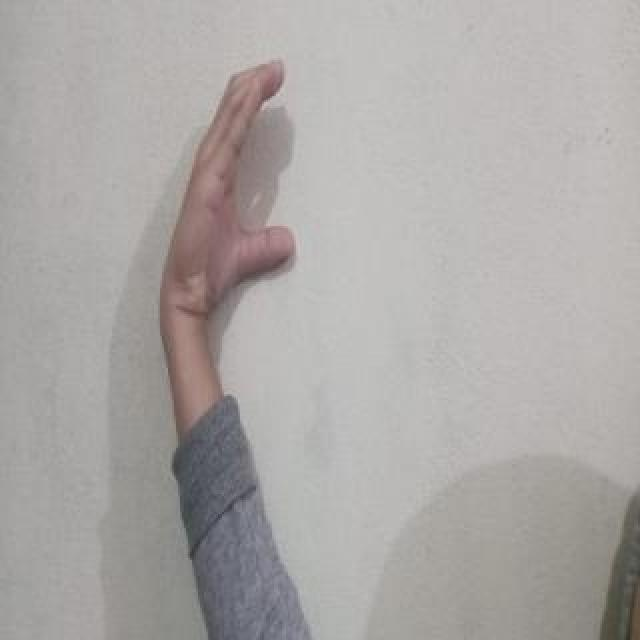

Displaying image 5: Dopahar_47_jpg.rf.838d72db2268a102d28b5a76158fad76.jpg


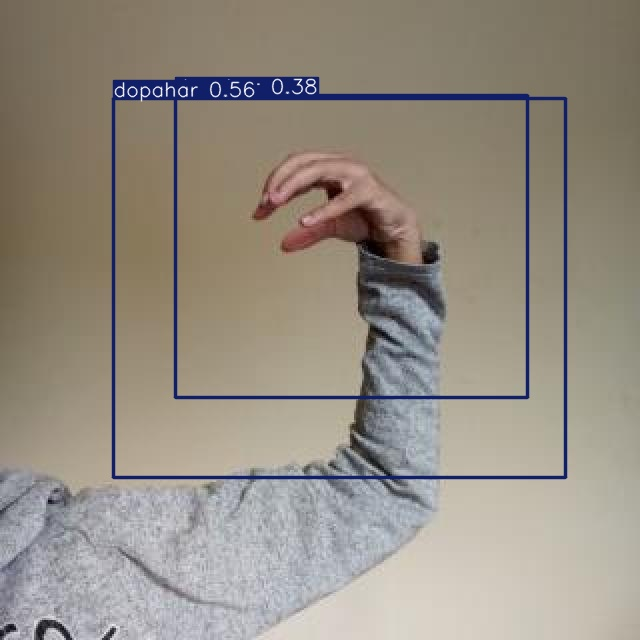

Displaying image 6: aaj_12_jpg.rf.af248df723872bd97243e7558bc33dec.jpg


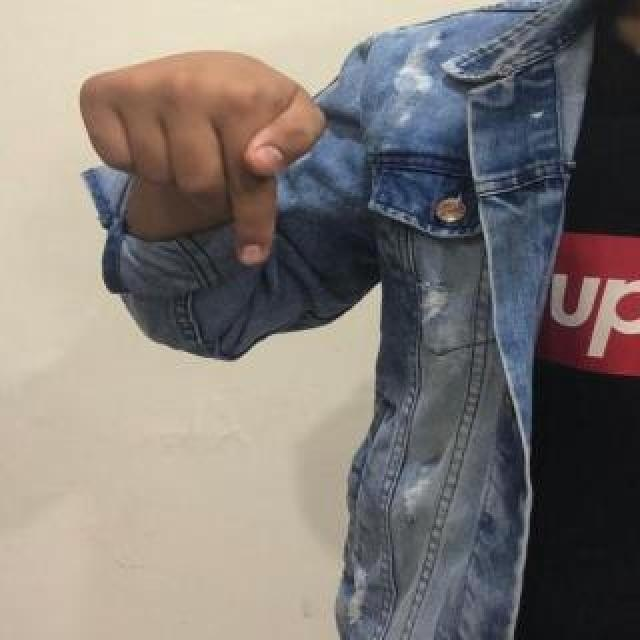

Displaying image 7: aaj_16_jpg.rf.f1cbd4850e0dfc9093eae2503a0d5cd9.jpg


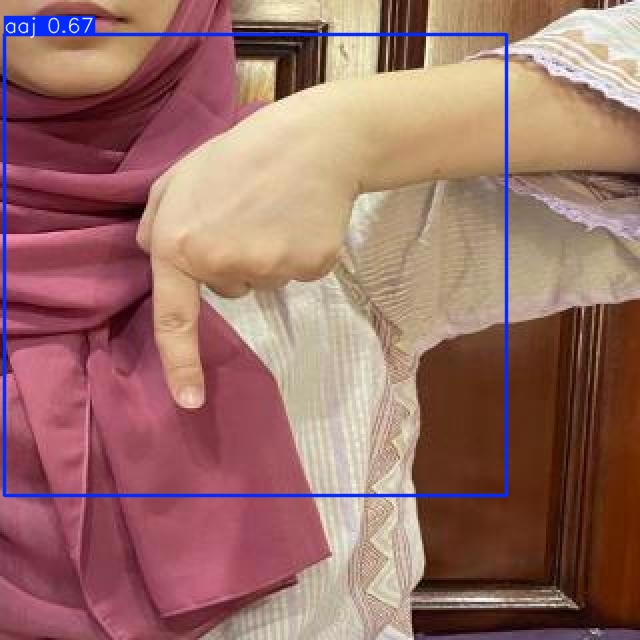

Displaying image 8: aaj_17_jpg.rf.c8ec968f013519234ec94f0add69213d.jpg


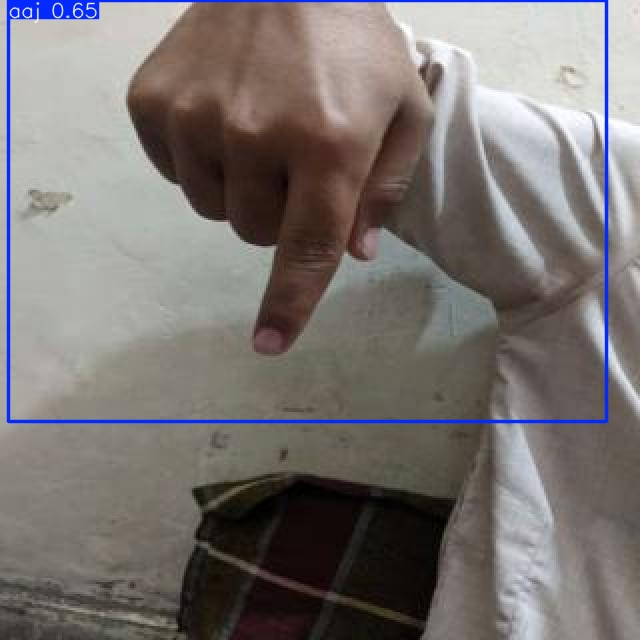

Displaying image 9: aaj_44_jpg.rf.3969f8d17c0395bbc769bb30a749db5b.jpg


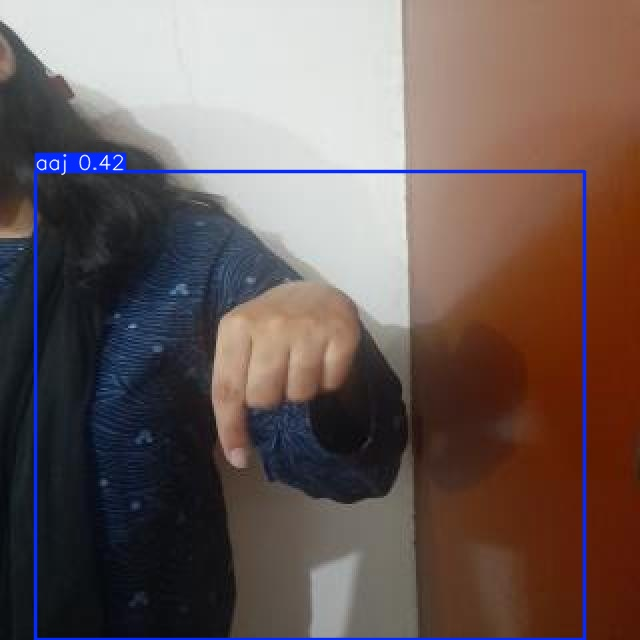

Displaying image 10: aaj_48_jpg.rf.db9135a7b3c6ce1b8434cd621d8e9317.jpg


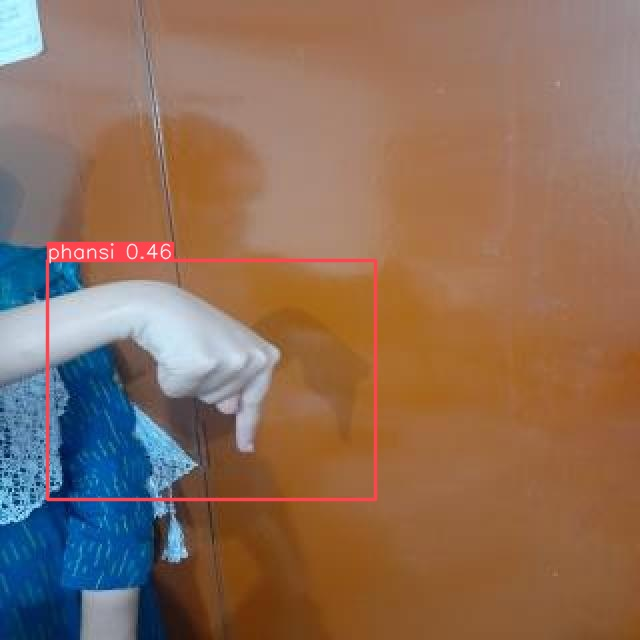

In [14]:
import os
from IPython.display import Image, display

predict_dir = '/kaggle/working/runs/detect/predict'
image_files = [f for f in os.listdir(predict_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

image_files.sort()

print(f"Found {len(image_files)} predicted images. Displaying the first 10:")

for i, image_file in enumerate(image_files[:10]):
    print(f"Displaying image {i+1}: {image_file}")
    display(Image(filename=os.path.join(predict_dir, image_file)))

### **Exporting the best.pt weight model file into ONNX format**

In [15]:
# Load best trained model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

# Export to ONNX with 'simplify' enabled for better performance
model.export(format='onnx', simplify=True)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11m summary (fused): 126 layers, 20,114,842 parameters, 0 gradients, 68.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 114, 8400) (38.8 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 240ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 3.38s
Installed 2 packages in 16ms
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 4.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim

'/kaggle/working/runs/detect/train/weights/best.onnx'

### **Zipping the Output folder for saving locally**

In [16]:
!zip -r outputs.zip /kaggle/working/runs/detect


  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/val/ (stored 0%)
  adding: kaggle/working/runs/detect/val/predictions.json (deflated 75%)
  adding: kaggle/working/runs/detect/val/val_batch2_pred.jpg (deflated 9%)
  adding: kaggle/working/runs/detect/val/BoxPR_curve.png (deflated 22%)
  adding: kaggle/working/runs/detect/val/val_batch0_pred.jpg (deflated 10%)
  adding: kaggle/working/runs/detect/val/BoxR_curve.png (deflated 9%)
  adding: kaggle/working/runs/detect/val/BoxP_curve.png (deflated 13%)
  adding: kaggle/working/runs/detect/val/val_batch2_labels.jpg (deflated 9%)
  adding: kaggle/working/runs/detect/val/val_batch1_pred.jpg (deflated 9%)
  adding: kaggle/working/runs/detect/val/val_batch0_labels.jpg (deflated 11%)
  adding: kaggle/working/runs/detect/val/confusion_matrix_normalized.png (deflated 20%)
  adding: kaggle/working/runs/detect/val/confusion_matrix.png (deflated 20%)
  adding: kaggle/working/runs/detect/val/BoxF1_curve.png (deflat